<a href="https://colab.research.google.com/github/mugalan/moodle-quiz-creation/blob/main/Moodle_Ai_Quiz_creation_API_Cookbook_Public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Instructions

This notebook sets up an environment to interact with an external API to save and create MOODLE MCQ quizzes.

1. You can create your quizzes using the following openAI GPT

      [Mugas Quiz Creator GPT](https://chatgpt.com/g/g-687de661eb948191805df6aaa5c1acf5-mcq-quiz-generator)

2. Specify the topic, the number of questions and the level (ex: Undergraduate Sophoomore) and the GPT will give you a structured output that you have simply copy and paste in the cell block blow **Step 2 - Assign the GPT output to the varaible records**.

3. Next run the code below the cell block titled **Step 3 - Preview and save the quiz** to preview the quiz by clicking the url.

4. If you are happy with the quiz run the code below the cell block titled **Step 4 - Create Moodle Quiz** to generate the moodle quiz.

5. Visit the generated url and you can dowload the H5P

6. **Important:** Run the code bellow the section 'Initialization' to initialize the quiz creation flow. It includes functions to call the API and save quiz data and sets the API token, webserviceurl, and previewurl.



#Initialization

In [19]:
!pip install xmltodict

In [ ]:
import copy
import xmltodict
def create_moodle_quiz(questionsdict):
    '''

    '''
    answerdict={'@fraction': '0',
                '@format': 'html',
                'text': '<p dir="ltr" style="text-align: left;">Choice<br></p>',
                'feedback': {'@format': 'html', 'text': 'none'}}
    questionict={'@type': 'multichoice',
                'name': {'text': 'Quation Name1'},
                'questiontext': {'@format': 'html','text': '<p dir="ltr" style="text-align: left;"></p><p>Text 1<p></p>'},
                'generalfeedback': {'@format': 'html', 'text': 'none'},
                'defaultgrade': '1',
                'penalty': '0',
                'hidden': '0',
                'idnumber': 'none',
                'single': 'true',
                'shuffleanswers': 'true',
                'answernumbering': 'none',
                'showstandardinstruction': '0',
                'correctfeedback': {'@format': 'html', 'text': 'Your answer is correct.'},
                'partiallycorrectfeedback': {'@format': 'html',
                'text': 'Your answer is partially correct.'},
                'incorrectfeedback': {'@format': 'html', 'text': 'Your answer is incorrect.'},
                'shownumcorrect': 'none',
                'answer': [answerdict]}
    xml_dict={'quiz':{'question':[questionict]}}
    question=[]
    for dct in questionsdict:
        qdct=copy.deepcopy(questionict)
        qdct['name']['text']=dct['name']
        dct.pop('name')
        qdct['defaultgrade']=dct['grade']
        dct.pop('grade')
        qdct['questiontext']['text']= '<p dir="ltr" style="text-align: left;"></p><p>{}<p></p>'.format(dct['question'])
        dct.pop('question')
        answer=[]
        for ky in [*dct]:
            adct=copy.deepcopy(answerdict)
            if dct[ky] not in ['',None]:
                if ky=='correct':
                    adct['@fraction']='100'
                    adct['text']='<p dir="ltr" style="text-align: left;">{}<br></p>'.format(dct[ky])
                else:
                    adct['@fraction']='0'
                    adct['text']='<p dir="ltr" style="text-align: left;">{}<br></p>'.format(dct[ky])
                answer+=[adct]
                qdct['answer']=answer
        question+=[qdct]
    xml_dict={'quiz':{'question':question}}
    xml_data = xmltodict.unparse(xml_dict, pretty=True)
    status='success'
    message="Moodle XML quiz generated"
    meta_data=message
    response = {"meta_data": meta_data, "xml":xml_data, "message":message}
    return {"status": status, "response": response}

def save_quiz_xml(filename, xml_content=''):

    if xml_content:
        with open('quiz.xml', 'w', encoding='utf-8') as f:
            f.write(xml_content)
        print("XML content saved to 'quiz.xml'")
    else:
        print("No XML content found to save.")

#Moodle Quiz Creation

## Step 1 - Create the quiz data using the openAI GPT

Create your moodle quiz by following the link to the customized GPT below. It produces the quiz in a JSON fromat of a list of dictionaries.

https://chatgpt.com/g/g-687de661eb948191805df6aaa5c1acf5-mcq-quiz-generator

## Step 2 - Assign the GPT output to the varaible records

Copy and paste the structured output of the GPT and assign it to the variable records as shown in the example below:

###Example screenshot

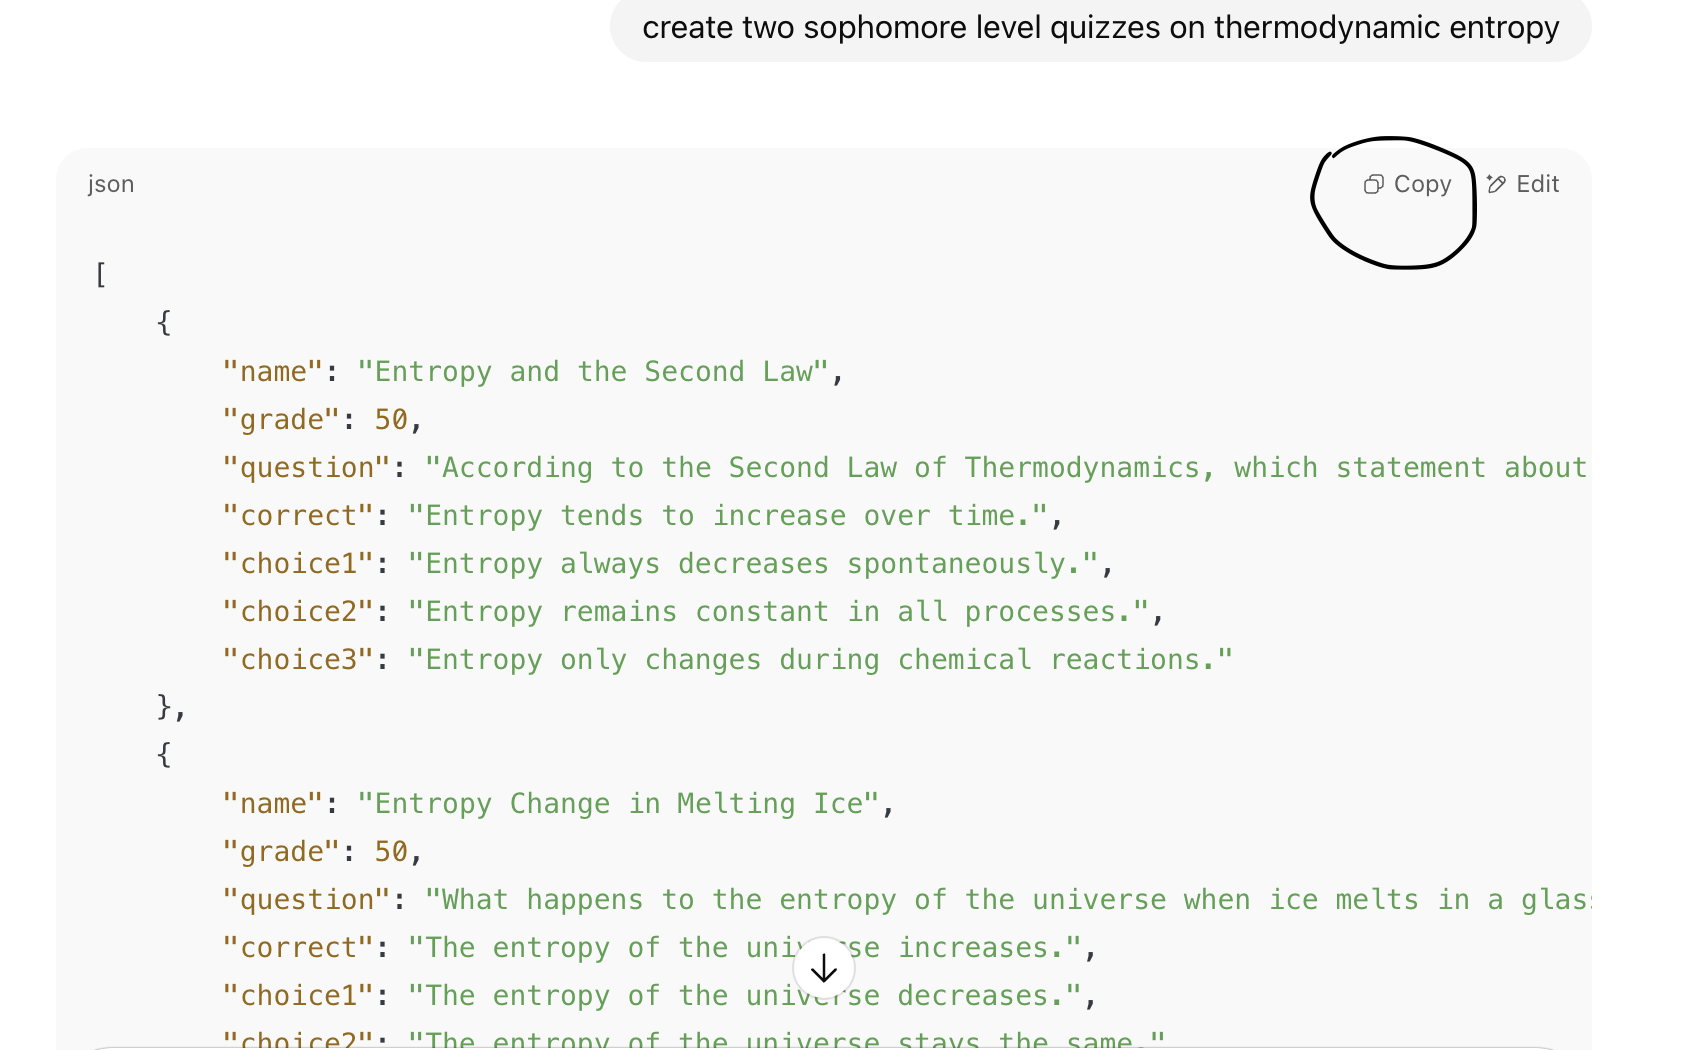

### Assign the variable record

In [ ]:
records=[
    {
        "name": "Entropy and the Second Law",
        "grade": 50,
        "question": "According to the Second Law of Thermodynamics, which statement about entropy is correct for an isolated system?",
        "correct": "Entropy tends to increase over time.",
        "choice1": "Entropy always decreases spontaneously.",
        "choice2": "Entropy remains constant in all processes.",
        "choice3": "Entropy only changes during chemical reactions."
    },
    {
        "name": "Entropy Change in Melting Ice",
        "grade": 50,
        "question": "What happens to the entropy of the universe when ice melts in a glass of water at room temperature?",
        "correct": "The entropy of the universe increases.",
        "choice1": "The entropy of the universe decreases.",
        "choice2": "The entropy of the universe stays the same.",
        "choice3": "The entropy of the system decreases while the surroundings increase equally."
    }
]

In [ ]:
records=[
{
"name": "場所をたずねる",
"grade": 50,
"question": "「スーパーはどこですか。」の意味は何ですか？",
"correct": "Supermarket එක කොහෙද?",
"choice1": "Supermarket එක කොහොමද?",
"choice2": "Supermarket එක මොකක්ද?",
"choice3": "Supermarket එක කීයටද?",
"choice4": "Supermarket එක කවුරුද?"
},
{
"name": "道案内の依頼",
"grade": 50,
"question": "「ぎんこうはどちらですか。」と聞いたら、あなたは何を探していますか？",
"correct": "Bank එක",
"choice1": "Hospital එක",
"choice2": "Station එක",
"choice3": "Restaurant එක",
"choice4": "Park එක"
}
]


## Step 3 - Preview and save the quiz

Set the following:

 - title
 - keywords
 - grade (set to 100 by default)

In [ ]:
title = 'Sophomore Level Quiz on Thermodynamic Entropy'
keywords=['Sophomore','Thermodynamics', 'Entropy']
url, refs, errors = save_quiz(records,title,grade=100,keywords=keywords)
print(f'Preview: {url}')
if refs:
    quiz_ref=refs[0].get('ref','')
    print(f'Please use this ref if you want to create a moodle quiz: {quiz_ref}')
else:
    print(f'Save unsuccessful: {errors}')

201
Errors: []
Updated: [{'ref': '49da195b-adb9-46ab-b491-a0ad7a7f12d8'}]
Preview: https://lms.orise.lk/dev/app/h5p_mcq_quiz/49da195b-adb9-46ab-b491-a0ad7a7f12d8/
Please use this ref if you want to create a moodle quiz: 49da195b-adb9-46ab-b491-a0ad7a7f12d8


## Step 4 - Create Moodle Quiz

If you are happy with the create run the code below to create the moodle quiz.

In [ ]:
apimethod = 'create_hvp_quiz_from_quiz_ref_public'
apidata = {'quiz_ref':quiz_ref,'title':title}
response = call_omdAPI(webserviceurl, token, apimethod, apidata)
meta_data = response.json().get('response',{}).get('meta_data','')
url=meta_data.get('url','')
print(url)

https://lms.orise.lk/dev_moodle/mod/hvp/view.php?id=1070
